<a href="https://colab.research.google.com/github/maximilianof910-lab/Trabajo-final-herramientas-basicas-de-analisis/blob/main/trabajofinalmaximilianofernandez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Trabajo Final - Maximiliano Fernandez

# README: Análisis de Transferencias de Motovehículos

Este proyecto se enfoca en el análisis de las transferencias de motovehículos en Argentina a lo largo de varios años, utilizando datos históricos para identificar tendencias y patrones.

## Objetivo
El objetivo principal es realizar un análisis exhaustivo de las transferencias de motovehículos en los últimos años para comprender su evolución y distribución.

## Fuente de Datos
Los datos utilizados para este análisis provienen de la siguiente fuente oficial:
*   [Estadística de Trámites de Motovehículos - Datos.gob.ar](https://www.datos.gob.ar/dataset/justicia-estadistica-tramites-motovehiculos/archivo/justicia_6422d3c8-fa7d-47b4-96e9-4b2f2fab1e90)

## Preguntas de Análisis Resueltas
Durante este informe, se buscan responder las siguientes preguntas clave:

1.  ¿Cuál es la tendencia general de las transferencias de motovehículos a lo largo de los años?
2.  ¿Cuáles son las tres provincias con mayor cantidad de transferencias?
3.  ¿Existe una tendencia mensual en las transferencias de motovehículos?
4.  ¿Cómo se distribuyen las transferencias entre todas las provincias?
5.  ¿Cómo se comparan las transferencias del primer trimestre en los últimos cuatro años?

## Estructura del Notebook
El cuaderno sigue una estructura lógica que incluye:
*   **Importación de Librerías**: Carga de las bibliotecas necesarias como pandas, numpy, matplotlib y seaborn.
*   **Búsqueda y Selección del Dataset**: Carga del archivo CSV y revisión inicial de los datos.
*   **Ingesta y Limpieza**: Auditoría de tipos de datos, valores nulos, duplicados y detección de outliers. Eliminación de columnas no relevantes (`letra_provincia_transferencia`, `provincia_id`).
*   **Estandarización**: Conversión de `anio_transferencia` y `mes_transferencia` a una columna de fecha (`fecha_transferencia`) y estandarización de categorías.
*   **Exploración y Visualización**: Desarrollo de gráficos y análisis para responder a las preguntas planteadas.

## Importar librerias

In [2]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Búsqueda y selección del dataset

In [3]:
data = pd.read_csv('/content/drive/MyDrive/estadistica-transferencias-motovehiculos-2007-01-2026-03.csv')

*   Fuente: https://www.datos.gob.ar/dataset/justicia-estadistica-tramites-motovehiculos/archivo/justicia_6422d3c8-fa7d-47b4-96e9-4b2f2fab1e90
*   Objetivo: realizar un analisis  de las  transferencias de motovehiculos en los ultimos años.
*   Preguntas de analisis:

1.   ¿tendencia de las tranferencias durantes esto años?

1. ¿Las tres provincias con mas transferencias?
2.   ¿Tendencia de las transferencias por mes?
4. ¿Distribución de Transferencias por todas las Provincias?
5. ¿Comparación de las transferencias para el primer trimestre de los ultimos 4 años?











In [4]:
data.head( )

,tipo_vehiculo,anio_transferencia,mes_transferencia,provincia_transferencia,letra_provincia_transferencia,cantidad_transferencias,provincia_id
0,Motovehículos,2007,1,Buenos Aires,B,2419,6
1,Motovehículos,2007,1,Catamarca,K,25,10
2,Motovehículos,2007,1,Chaco,H,152,22
3,Motovehículos,2007,1,Chubut,U,46,26
4,Motovehículos,2007,1,Ciudad Autónoma de Bs.As.,C,360,2


In [5]:
data.shape

(5544, 7)

In [6]:
data. info ( )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5544 entries, 0 to 5543
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   tipo_vehiculo                  5544 non-null   object
 1   anio_transferencia             5544 non-null   int64 
 2   mes_transferencia              5544 non-null   int64 
 3   provincia_transferencia        5544 non-null   object
 4   letra_provincia_transferencia  5544 non-null   object
 5   cantidad_transferencias        5544 non-null   int64 
 6   provincia_id                   5544 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 303.3+ KB


In [7]:
data.dtypes

,0
tipo_vehiculo,object
anio_transferencia,int64
mes_transferencia,int64
provincia_transferencia,object
letra_provincia_transferencia,object
cantidad_transferencias,int64
provincia_id,int64


## Ingesta y limpieza (Python)

In [8]:
data.columns

Index(['tipo_vehiculo', 'anio_transferencia', 'mes_transferencia',
       'provincia_transferencia', 'letra_provincia_transferencia',
       'cantidad_transferencias', 'provincia_id'],
      dtype='object')

In [9]:
for col in data.columns:
    if data[col].nunique() < 50:
        print(f"Column: {col}\nUnique Values: {data[col].unique()}\n")
    else:
        print(f"Column: {col}\nNumber of Unique Values: {data[col].nunique()}\n")

Column: tipo_vehiculo
Unique Values: ['Motovehículos']

Column: anio_transferencia
Unique Values: [2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020
 2021 2022 2023 2024 2025 2026]

Column: mes_transferencia
Unique Values: [ 1  2  3  4  5  6  7  8  9 10 11 12]

Column: provincia_transferencia
Unique Values: ['Buenos Aires' 'Catamarca' 'Chaco' 'Chubut' 'Ciudad Autónoma de Bs.As.'
 'Córdoba' 'Corrientes' 'Entre Ríos' 'Formosa' 'Jujuy' 'La Pampa'
 'La Rioja' 'Mendoza' 'Misiones' 'Neuquén' 'Río Negro' 'Salta' 'San Juan'
 'San Luis' 'Santa Cruz' 'Santa Fe' 'Santiago del Estero'
 'Tierra del Fuego' 'Tucumán']

Column: letra_provincia_transferencia
Unique Values: ['B' 'K' 'H' 'U' 'C' 'X' 'W' 'E' 'P' 'Y' 'L' 'F' 'M' 'N' 'Q' 'R' 'A' 'J'
 'D' 'Z' 'S' 'G' 'V' 'T']

Column: cantidad_transferencias
Number of Unique Values: 1885

Column: provincia_id
Unique Values: [ 6 10 22 26  2 14 18 30 34 38 42 46 50 54 58 62 66 70 74 78 82 86 94 90]



### Se procede a la eliminacion de las columnas: letra_provincia_transferencia y provincia_id ya que no son relativas para el analisis

In [10]:
data = data.drop(columns=['letra_provincia_transferencia', 'provincia_id'])
display(data.head())

,tipo_vehiculo,anio_transferencia,mes_transferencia,provincia_transferencia,cantidad_transferencias
0,Motovehículos,2007,1,Buenos Aires,2419
1,Motovehículos,2007,1,Catamarca,25
2,Motovehículos,2007,1,Chaco,152
3,Motovehículos,2007,1,Chubut,46
4,Motovehículos,2007,1,Ciudad Autónoma de Bs.As.,360


In [11]:
for col in data.columns:
    if data[col].nunique() < 50:
        print(f"Column: {col}\nUnique Values: {data[col].unique()}\n")
    else:
        print(f"Column: {col}\nNumber of Unique Values: {data[col].nunique()}\n")

Column: tipo_vehiculo
Unique Values: ['Motovehículos']

Column: anio_transferencia
Unique Values: [2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020
 2021 2022 2023 2024 2025 2026]

Column: mes_transferencia
Unique Values: [ 1  2  3  4  5  6  7  8  9 10 11 12]

Column: provincia_transferencia
Unique Values: ['Buenos Aires' 'Catamarca' 'Chaco' 'Chubut' 'Ciudad Autónoma de Bs.As.'
 'Córdoba' 'Corrientes' 'Entre Ríos' 'Formosa' 'Jujuy' 'La Pampa'
 'La Rioja' 'Mendoza' 'Misiones' 'Neuquén' 'Río Negro' 'Salta' 'San Juan'
 'San Luis' 'Santa Cruz' 'Santa Fe' 'Santiago del Estero'
 'Tierra del Fuego' 'Tucumán']

Column: cantidad_transferencias
Number of Unique Values: 1885



## Auditar tipos, nulos, duplicados y outliers.

In [12]:
print('Null values in each column:')
display(data.isnull().sum())

Null values in each column:


,0
tipo_vehiculo,0
anio_transferencia,0
mes_transferencia,0
provincia_transferencia,0
cantidad_transferencias,0


In [13]:
print(f"Number of duplicate rows: {data.duplicated().sum()}")

Number of duplicate rows: 0


## Detección de valores atípicos usando el método IQR




In [14]:
Q1 = data['cantidad_transferencias'].quantile(0.25)
Q3 = data['cantidad_transferencias'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['cantidad_transferencias'] < lower_bound) | (data['cantidad_transferencias'] > upper_bound)]

print(f"Number of outliers: {len(outliers)}")
print("Outliers (first 5 rows if any):")
display(outliers.head())

Number of outliers: 793
Outliers (first 5 rows if any):


,tipo_vehiculo,anio_transferencia,mes_transferencia,provincia_transferencia,cantidad_transferencias
0,Motovehículos,2007,1,Buenos Aires,2419
5,Motovehículos,2007,1,Córdoba,2078
24,Motovehículos,2007,2,Buenos Aires,2116
29,Motovehículos,2007,2,Córdoba,1871
48,Motovehículos,2007,3,Buenos Aires,2469


Si bien se observan valores atipicos se tendran en cuenta a la hora de realizar este informe dado que la fuente es oficial y las transferencias a lo largo de estos años han sufrido subas y sobre todo bajas atipicas explicado por la situacion economica del pais.

## Estandarizar fechas, categorías y unidades.

### Estandarización de fecha

In [15]:
# Combinar 'anio_transferencia' y 'mes_transferencia' para crear una columna de fecha
data['fecha_transferencia'] = pd.to_datetime(data['anio_transferencia'].astype(str) + '-' + data['mes_transferencia'].astype(str) + '-01')

print('Primeras 5 filas con la nueva columna de fecha:')
display(data.head())

Primeras 5 filas con la nueva columna de fecha:


,tipo_vehiculo,anio_transferencia,mes_transferencia,provincia_transferencia,cantidad_transferencias,fecha_transferencia
0,Motovehículos,2007,1,Buenos Aires,2419,2007-01-01
1,Motovehículos,2007,1,Catamarca,25,2007-01-01
2,Motovehículos,2007,1,Chaco,152,2007-01-01
3,Motovehículos,2007,1,Chubut,46,2007-01-01
4,Motovehículos,2007,1,Ciudad Autónoma de Bs.As.,360,2007-01-01


### Estandarización de Categorías

In [16]:
# Convertir la columna 'provincia_transferencia' a tipo categórico
data['provincia_transferencia'] = data['provincia_transferencia'].astype('category')

print('Tipos de datos actualizados:')
display(data.dtypes)

Tipos de datos actualizados:


,0
tipo_vehiculo,object
anio_transferencia,int64
mes_transferencia,int64
provincia_transferencia,category
cantidad_transferencias,int64
fecha_transferencia,datetime64[ns]


### Estandarización de Unidades/Fórmulas

La columna `cantidad_transferencias` ya es numérica y no requiere una estandarización de unidad adicional en este punto. Si se requieren nuevas métricas o transformaciones (fórmulas), se pueden añadir aquí.

## Exploracíon y visualización

### 1. Tendencia de las transferencias a lo largo de los años

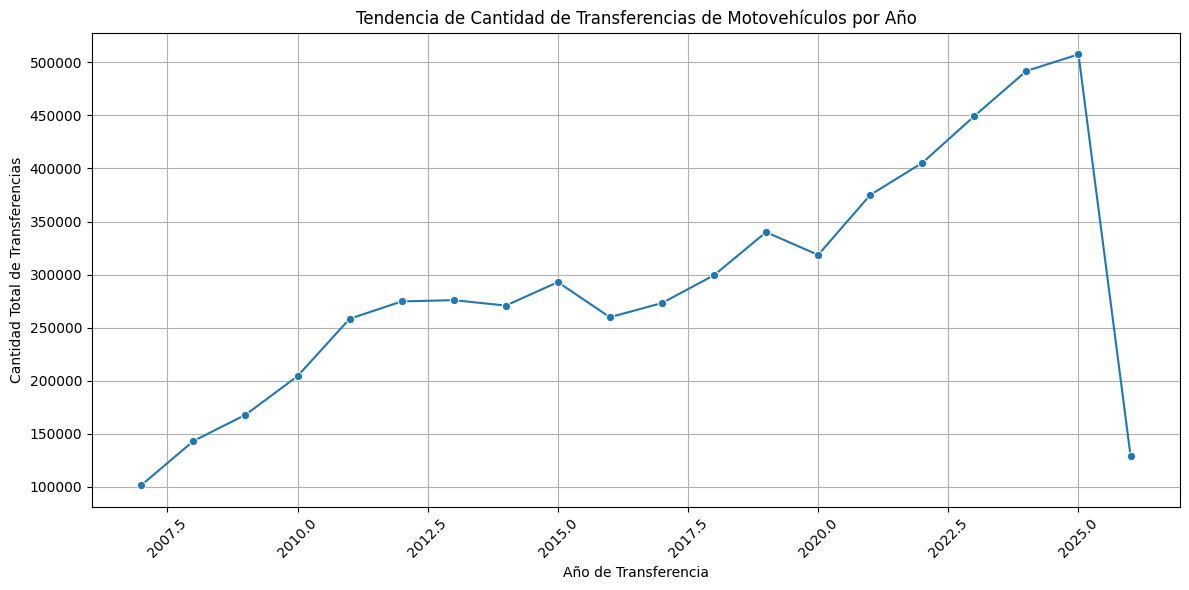

In [17]:
# Agrupar por año y sumar las transferencias
transfers_by_year = data.groupby('anio_transferencia')['cantidad_transferencias'].sum().reset_index()

# Crear el gráfico de línea
plt.figure(figsize=(12, 6))
sns.lineplot(x='anio_transferencia', y='cantidad_transferencias', data=transfers_by_year, marker='o')
plt.title('Tendencia de Cantidad de Transferencias de Motovehículos por Año')
plt.xlabel('Año de Transferencia')
plt.ylabel('Cantidad Total de Transferencias')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Respuesta a la pregunta numero uno, podemos observar una tendencia a la alta en transferencias en el pais. N o tiene en cuentas los datos del año 2026 ya que solo cuenta con tres meses de datos y no puede hacer una lectura anual.


###  2. Las tres provincias con más transferencias

Top 3 provincias con más transferencias:


/tmp/ipykernel_12547/3268191277.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  transfers_by_province = data.groupby('provincia_transferencia')['cantidad_transferencias'].sum().reset_index()


,provincia_transferencia,cantidad_transferencias
0,Buenos Aires,2166767
6,Córdoba,932118
20,Santa Fe,810673


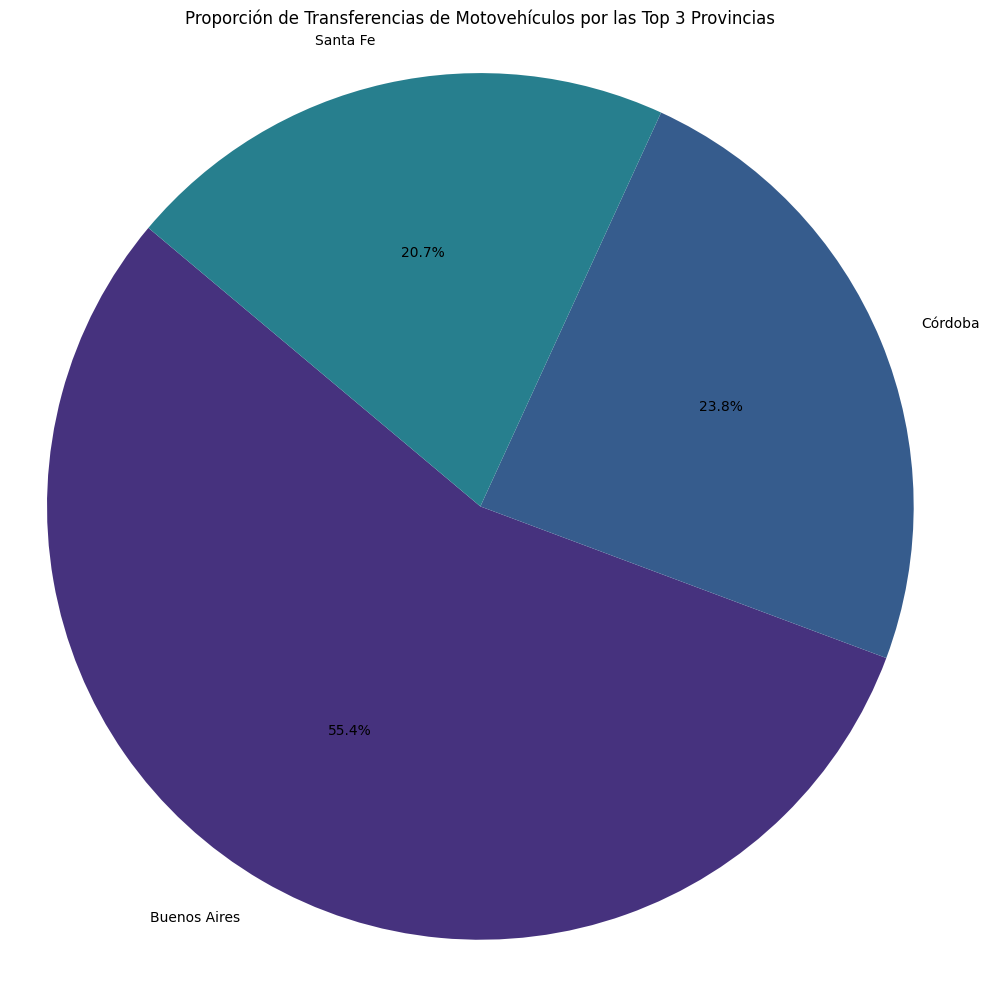

In [18]:
# Agrupar por provincia y sumar las transferencias
transfers_by_province = data.groupby('provincia_transferencia')['cantidad_transferencias'].sum().reset_index()

# Ordenar y seleccionar las top 3 provincias
top_3_provinces = transfers_by_province.sort_values(by='cantidad_transferencias', ascending=False).head(3)

print("Top 3 provincias con más transferencias:")
display(top_3_provinces)

# Crear un gráfico de torta para visualizar la proporción de transferencias entre las top 3 provincias
plt.figure(figsize=(10, 10))
plt.pie(top_3_provinces['cantidad_transferencias'],
        labels=top_3_provinces['provincia_transferencia'],
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('viridis'))
plt.title('Proporción de Transferencias de Motovehículos por las Top 3 Provincias')
plt.axis('equal') # Asegura que el círculo sea proporcional
plt.tight_layout()
plt.show()

### 3. Tendencia de las transferencias por mes

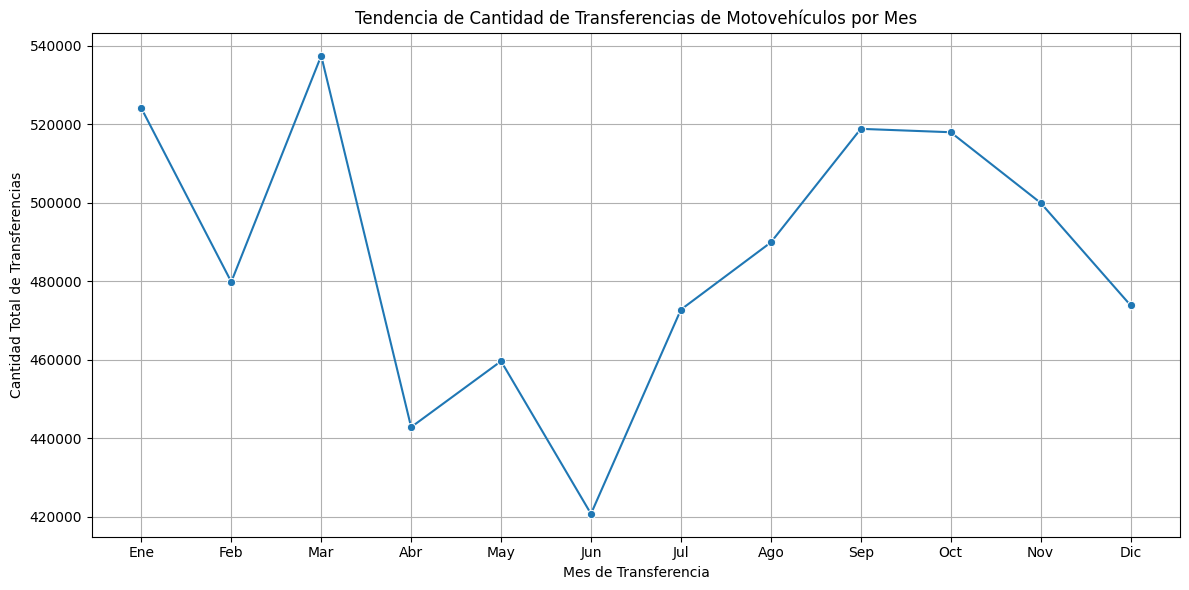

In [19]:
# Agrupar por mes y sumar las transferencias
transfers_by_month = data.groupby('mes_transferencia')['cantidad_transferencias'].sum().reset_index()

# Crear el gráfico de línea
plt.figure(figsize=(12, 6))
sns.lineplot(x='mes_transferencia', y='cantidad_transferencias', data=transfers_by_month, marker='o')
plt.title('Tendencia de Cantidad de Transferencias de Motovehículos por Mes')
plt.xlabel('Mes de Transferencia')
plt.ylabel('Cantidad Total de Transferencias')
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.grid(True)
plt.tight_layout()
plt.show()

### 4. Distribución de Transferencias por todas las Provincias

/tmp/ipykernel_12547/524965008.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  transfers_by_province_all = data.groupby('provincia_transferencia')['cantidad_transferencias'].sum().reset_index()
/tmp/ipykernel_12547/524965008.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cantidad_transferencias', y='provincia_transferencia', data=transfers_by_province_all, palette='viridis')


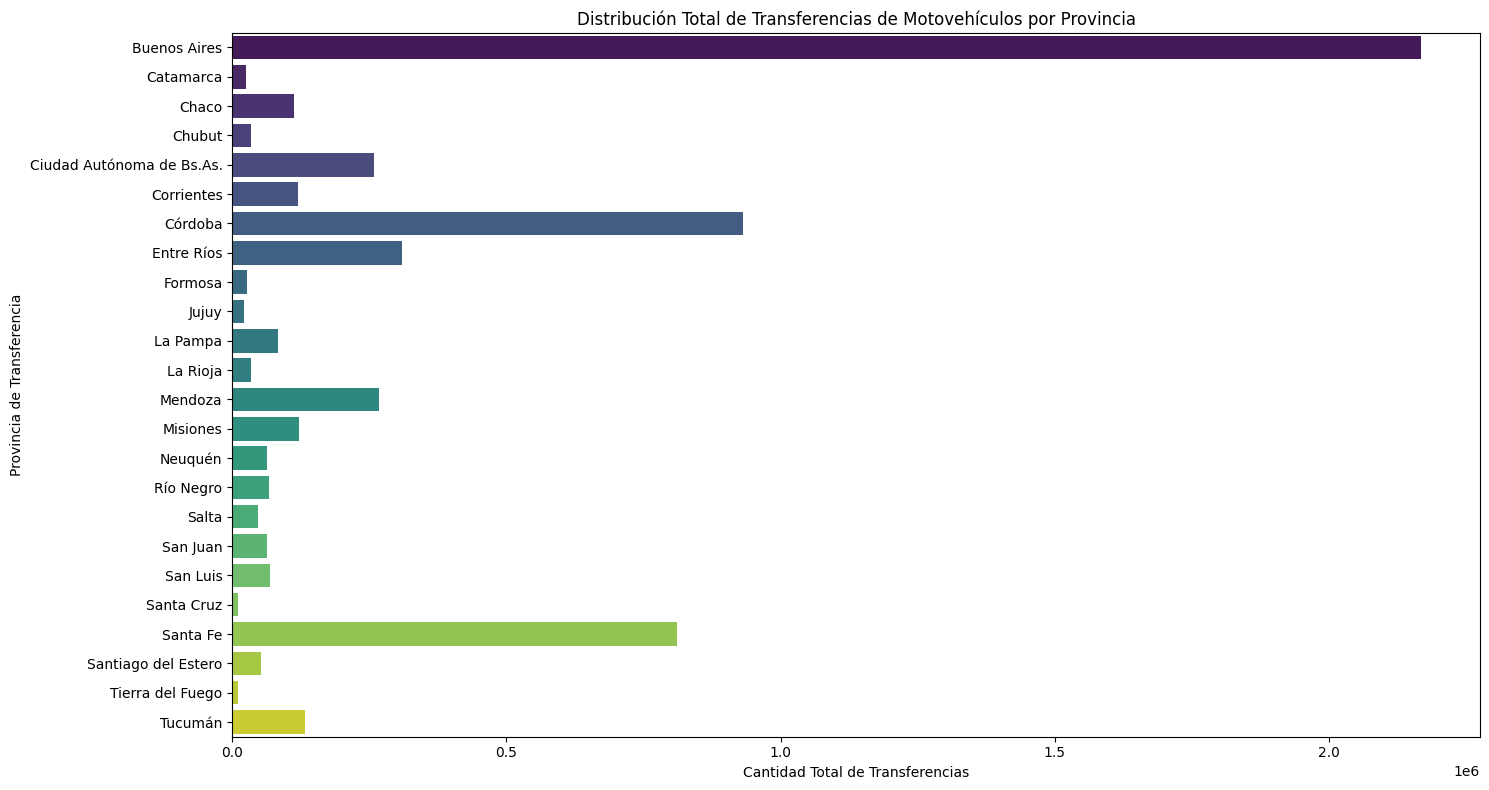

In [20]:
# Agrupar por provincia y sumar las transferencias
transfers_by_province_all = data.groupby('provincia_transferencia')['cantidad_transferencias'].sum().reset_index()

# Ordenar por cantidad de transferencias para una mejor visualización
transfers_by_province_all = transfers_by_province_all.sort_values(by='cantidad_transferencias', ascending=False)

# Crear el gráfico de barras
plt.figure(figsize=(15, 8))
sns.barplot(x='cantidad_transferencias', y='provincia_transferencia', data=transfers_by_province_all, palette='viridis')
plt.title('Distribución Total de Transferencias de Motovehículos por Provincia')
plt.xlabel('Cantidad Total de Transferencias')
plt.ylabel('Provincia de Transferencia')
plt.tight_layout()
plt.show()

### comparación de las transferencias para el primer trimestre de los ultimos 4 años.

Transferencias en el primer trimestre (Ene-Mar) para 2022-2026:


,anio_transferencia,cantidad_transferencias
15,2022,95050
16,2023,108714
17,2024,107639
18,2025,132371
19,2026,129144


/tmp/ipykernel_12547/2757350372.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='anio_transferencia', y='cantidad_transferencias', data=comparison_q1_multi_year, palette='viridis')


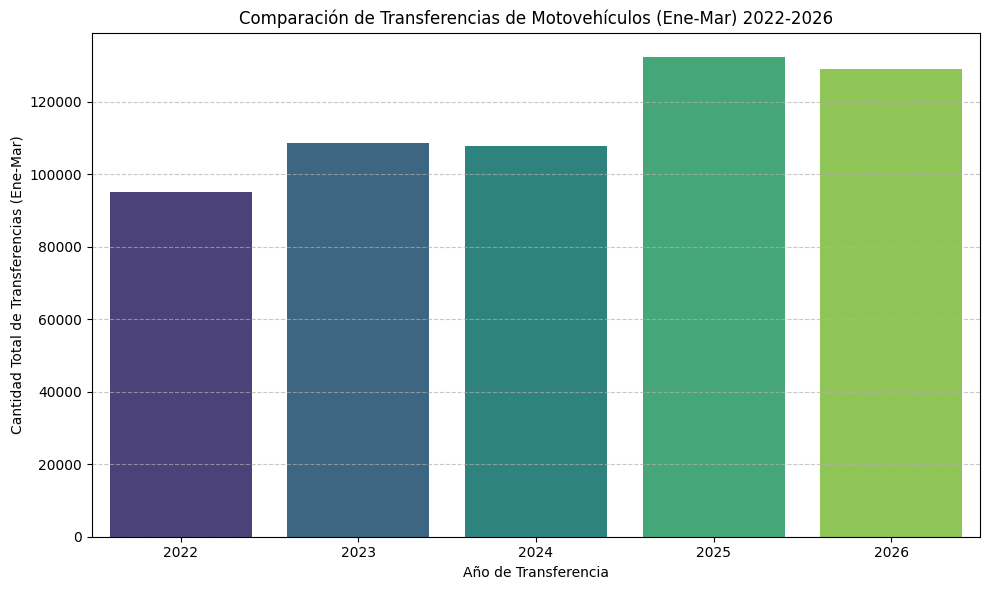

In [23]:
# Filtrar los datos para el primer trimestre (enero, febrero, marzo)
transfers_q1 = data[data['mes_transferencia'].isin([1, 2, 3])]

# Agrupar por año y sumar las transferencias para el primer trimestre
transfers_q1_by_year = transfers_q1.groupby('anio_transferencia')['cantidad_transferencias'].sum().reset_index()

# Filtrar los datos de transfers_q1_by_year para los años específicos
years_to_compare = [2022, 2023, 2024, 2025, 2026]
comparison_q1_multi_year = transfers_q1_by_year[transfers_q1_by_year['anio_transferencia'].isin(years_to_compare)]

print("Transferencias en el primer trimestre (Ene-Mar) para 2022-2026:")
display(comparison_q1_multi_year)

# Crear un gráfico de barras para la comparación
plt.figure(figsize=(10, 6))
sns.barplot(x='anio_transferencia', y='cantidad_transferencias', data=comparison_q1_multi_year, palette='viridis')
plt.title('Comparación de Transferencias de Motovehículos (Ene-Mar) 2022-2026')
plt.xlabel('Año de Transferencia')
plt.ylabel('Cantidad Total de Transferencias (Ene-Mar)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [24]:
data.to_csv('/content/trabajo_final.csv', index=False)
print('DataFrame guardado como /content/trabajo_final.csv')

DataFrame guardado como /content/trabajo_final.csv
